# Mid Term - Exploratory Data Analysis
By: Ranveer Thakur Chand, John Nasir, Trevor Oakum, Freddy Rodriguez

This cell imports all the libraries needed for the project, including pandas and numpy for data handling, matplotlib/seaborn for visualization, kagglehub for loading the dataset, and sklearn/imblearn for preprocessing and balancing. It also sets a default visual style for all plots in the notebook.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE


sns.set_style('whitegrid')

This cell loads the Rajasthan Heatwave dataset directly from Kaggle using kagglehub and prints its shape and column names to confirm it loaded correctly. It then immediately splits the data into a 70% training set and 30% test set, stratified on the HEATWAVE column, before any cleaning happens.


AI Disclaimer: AI (Gemini) was used to help write this code cell.
Prompt: "Write code to load a Kaggle dataset using kagglehub.dataset_load with the PANDAS adapter, print its shape and columns, then split it into 70% train and 30% test using train_test_split with stratify on the target column, before any preprocessing."

In [47]:
file_path = "Rajasthan_Heatwave_2006_2025.csv"
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "rupsarroy/heatwave-dataset-rajasthan-india-2006-2025",
  file_path,
)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

# Split BEFORE any exploration or cleaning, so test data stays completely untouched
train_df, test_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['HEATWAVE']
)

print("\nTraining set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Using Colab cache for faster access to the 'heatwave-dataset-rajasthan-india-2006-2025' dataset.
Dataset Loaded Successfully!
Shape: (21960, 23)

Columns: ['YEAR', 'MONTH', 'DAY', 'WIND_U10', 'WIND_V10', 'MSLP', 'BLH', 'GEOP', 'TEMP2M', 'TMAX', 'TMIN', 'DEW2M', 'CLOUD', 'RAIN', 'SRAD', 'EVAP', 'SOILT1', 'SOILM1', 'LAI', 'HEATWAVE', 'LAT', 'LON', 'DISTRICT']

Training set shape: (15372, 23)
Test set shape: (6588, 23)


This cell runs basic diagnostics on the training set only — checking data types, summary statistics, and missing values — to understand the data's structure. It also prints and plots the HEATWAVE class counts to show how imbalanced the training data is before any balancing is applied.


AI Disclaimer: AI (Gemini) was used to help write this code cell.
Prompt: "Write code that runs .info(), .describe(), and isnull().sum() on a training DataFrame, then prints value_counts and percentages for a target column called HEATWAVE, and plots the class distribution using seaborn's countplot."

--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 15372 entries, 13479 to 10040
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   YEAR      15372 non-null  int64  
 1   MONTH     15372 non-null  int64  
 2   DAY       15372 non-null  int64  
 3   WIND_U10  15372 non-null  float64
 4   WIND_V10  15372 non-null  float64
 5   MSLP      15372 non-null  float64
 6   BLH       15372 non-null  float64
 7   GEOP      15372 non-null  float64
 8   TEMP2M    15372 non-null  float64
 9   TMAX      15372 non-null  float64
 10  TMIN      15372 non-null  float64
 11  DEW2M     15372 non-null  float64
 12  CLOUD     15372 non-null  float64
 13  RAIN      15372 non-null  float64
 14  SRAD      15372 non-null  int64  
 15  EVAP      15372 non-null  float64
 16  SOILT1    15372 non-null  float64
 17  SOILM1    15372 non-null  float64
 18  LAI       15372 non-null  float64
 19  HEATWAVE  15372 non-null  int64  
 20  LA

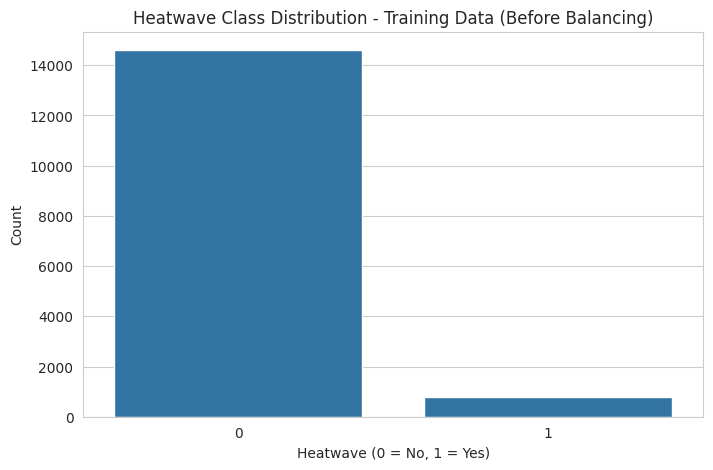

In [48]:
print("--- Training Data Info ---")
train_df.info()

print("\n--- Training Data Summary Statistics ---")
print(train_df.describe())

print("\n--- Missing values (training only) ---")
print(train_df.isnull().sum())

print("\nHEATWAVE value counts (training only):")
print(train_df['HEATWAVE'].value_counts())
print(train_df['HEATWAVE'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(x='HEATWAVE', data=train_df)
plt.title('Heatwave Class Distribution - Training Data (Before Balancing)')
plt.xlabel('Heatwave (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

This cell calculates the median for numeric columns and the mode for categorical columns using the training data only, then fills missing values in both the training and test sets using those same values. Computing the fill values from training data only prevents any information from the test set from leaking into preprocessing.


AI Disclaimer: AI (Gemini) was used to help write this code cell.
Prompt: "Write code that loops through a DataFrame's columns, computes the median for numeric columns and mode for categorical columns using only the training set, stores these in a dictionary, and applies fillna with that dictionary to both the training and test DataFrames."

In [49]:
# Compute fill values from training data only, then apply the SAME values to test.
# This avoids leaking any information from the test set into preprocessing.
fill_values = {}

for col in train_df.columns:
    if train_df[col].isnull().sum() > 0:
        if train_df[col].dtype in ['int64', 'float64']:
            fill_values[col] = train_df[col].median()
        else:
            fill_values[col] = train_df[col].mode()[0]

train_df = train_df.fillna(fill_values)
test_df = test_df.fillna(fill_values)

print("Missing values in training set after cleanup:")
print(train_df.isnull().sum().sum())
print("Missing values in test set after cleanup:")
print(test_df.isnull().sum().sum())

Missing values in training set after cleanup:
0
Missing values in test set after cleanup:
0


This cell checks whether the dataset has a combined date column that needs to be split into separate YEAR and MONTH features, applying the change to both train and test sets if one exists. Since our dataset already has YEAR, MONTH, and DAY as separate columns, this step doesn't change anything, but it's kept in to demonstrate the feature engineering technique required by the midterm guidelines.

AI Disclaimer: AI (Gemini) was used to help write this code cell.
Prompt: "Write code that checks a training and test DataFrame for a column with 'date' in its name, and if found, converts it to datetime and extracts YEAR and MONTH as new columns, dropping the original date column from both DataFrames. If no date column exists, print a message saying no feature engineering was needed."

In [50]:
# Feature engineering: extract YEAR and MONTH from a combined date column, if one exists.
# Our dataset already has YEAR/MONTH/DAY as separate columns, so this is a safety
# check rather than something that actually transforms our data.
date_cols = [c for c in train_df.columns if 'date' in c.lower()]

if date_cols:
    date_col = date_cols[0]
    for d in [train_df, test_df]:
        if date_col in d.columns:
            d[date_col] = pd.to_datetime(d[date_col])
            d['YEAR'] = d[date_col].dt.year
            d['MONTH'] = d[date_col].dt.month
            d.drop(columns=[date_col], inplace=True)
    print(f"Extracted YEAR and MONTH from '{date_col}' and dropped the original column.")
else:
    print("No combined date column found — YEAR/MONTH/DAY already exist as separate columns, so no feature engineering needed here.")

No combined date column found — YEAR/MONTH/DAY already exist as separate columns, so no feature engineering needed here.


This cell finds any text-based (categorical) columns in the training data, excluding the target column, and converts them into numeric one-hot encoded columns using pandas get_dummies. It then makes sure the test set has the exact same dummy columns as the training set, filling in any missing ones so both sets stay aligned.


AI Disclaimer: AI (Gemini) was used to help write this code cell.
Prompt: "Write code that identifies object-dtype (categorical) columns in a training DataFrame excluding the target column, one-hot encodes them with pd.get_dummies and drop_first=True on both train and test sets, then makes sure the test set has the same dummy columns as train by filling missing ones with False and reordering columns to match."

In [51]:
categorical_cols = [c for c in train_df.select_dtypes(include='object').columns if c != 'HEATWAVE']
print("Categorical columns to encode:", categorical_cols)

if categorical_cols:
    train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
    test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)
    # Make sure test has exactly the same dummy columns as train (in case a
    # category is missing from one split), filling any gaps with 0/False
    missing_cols_in_test = set(train_df.columns) - set(test_df.columns)
    for c in missing_cols_in_test:
        test_df[c] = False
    test_df = test_df[train_df.columns] # Ensure the order of columns is the same

print("\nEncoded Training Data Sample:")
print(train_df.head())
print("\nEncoded Test Data Sample:")
print(test_df.head())

Categorical columns to encode: ['DISTRICT']

Encoded Training Data Sample:
       YEAR  MONTH  DAY  WIND_U10  WIND_V10        MSLP        BLH       GEOP  \
13479  2016      4   29  2.639740  0.174927  100526.750  4711.8200  2133.9438   
4044   2019      3   19  3.612091  4.932159  100752.750  3083.8123  2180.9790   
10001  2007      6   28  2.452362  5.398529   99593.690  1781.5017  2038.4985   
7729   2009      4   13  2.454239 -1.089951  100427.750  3584.5864  4063.2250   
9479   2023      5   25  3.439438  0.307541  100440.625  1844.9446  4063.2250   

          TEMP2M       TMAX  ...    LAT    LON  DISTRICT_Bikaner  \
13479  316.01416  314.69410  ...  26.25  73.00             False   
4044   306.53590  305.72583  ...  28.00  73.25              True   
10001  307.34326  308.30030  ...  27.00  71.00             False   
7729   311.07544  310.61450  ...  27.00  75.75             False   
9479   303.31494  307.14062  ...  27.00  75.75             False   

       DISTRICT_Churu  DISTRI

This cell splits the training and test DataFrames into feature sets (X) and target labels (y), then identifies which numeric columns should be scaled while excluding the one-hot encoded DISTRICT columns. It fits a StandardScaler on the training features only and applies that same fitted scaler to the test features, preventing data leakage.


AI Disclaimer: AI (Gemini) was used to help write this code cell.
Prompt: "Write code that separates a target column called HEATWAVE from a training and test DataFrame into X_train, y_train, X_test, y_test, selects numeric columns for scaling while excluding columns starting with 'DISTRICT_', then fits a StandardScaler on X_train only and transforms both X_train and X_test with it."

In [52]:
X_train = train_df.drop(columns=['HEATWAVE'])
y_train = train_df['HEATWAVE']
X_test = test_df.drop(columns=['HEATWAVE'])
y_test = test_df['HEATWAVE']

# Identify numerical columns for scaling, excluding one-hot encoded 'DISTRICT_' columns
all_numeric_like_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
numeric_cols_to_scale = [col for col in all_numeric_like_cols if not col.startswith('DISTRICT_')]

# Keep raw (pre-transform) copies for both scaling and normalization demos
raw_numeric_train = X_train[numeric_cols_to_scale].copy()
before_scaling_sample = X_train[['TEMP2M', 'TMAX']].copy() # This is correct as it's from X_train before standardization

# --- Scaling (StandardScaler) ---
scaler = StandardScaler()
X_train[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("\nScaled training features sample:")
print(X_train.head())

Shape of X_train: (15372, 29)
Shape of X_test: (6588, 29)

Scaled training features sample:
           YEAR     MONTH       DAY  WIND_U10  WIND_V10      MSLP       BLH  \
13479  0.084146 -0.443933  1.504147  0.065923 -0.214428  0.159967  2.068718   
4044   0.604878 -1.339018  0.368607  0.472921  1.615292  0.587330  0.373781   
10001 -1.478048  1.346238  1.390593 -0.012508  1.794666 -1.604435 -0.982069   
7729  -1.130894 -0.443933 -0.312717 -0.011722 -0.700923 -0.027240  0.895143   
9479   1.299187  0.451153  1.049931  0.400653 -0.163422 -0.002894 -0.916018   

           GEOP    TEMP2M      TMAX  ...       LAT       LON  \
13479 -0.550726  1.145079  0.984445  ... -0.693603 -0.416484   
4044  -0.486398 -0.826509 -0.910211  ...  0.605314 -0.260603   
10001 -0.681262 -0.658569 -0.366323  ... -0.136924 -1.663532   
7729   2.087863  0.117768  0.122580  ... -0.136924  1.298208   
9479   2.087863 -1.496506 -0.611320  ... -0.136924  1.298208   

       DISTRICT_Bikaner  DISTRICT_Churu  DISTRIC

This cell creates a 2x2 grid of histograms comparing the TEMP2M and TMAX features before and after StandardScaler was applied. It visually confirms that scaling recenters the data around a mean of 0 without changing the overall shape of the distribution.

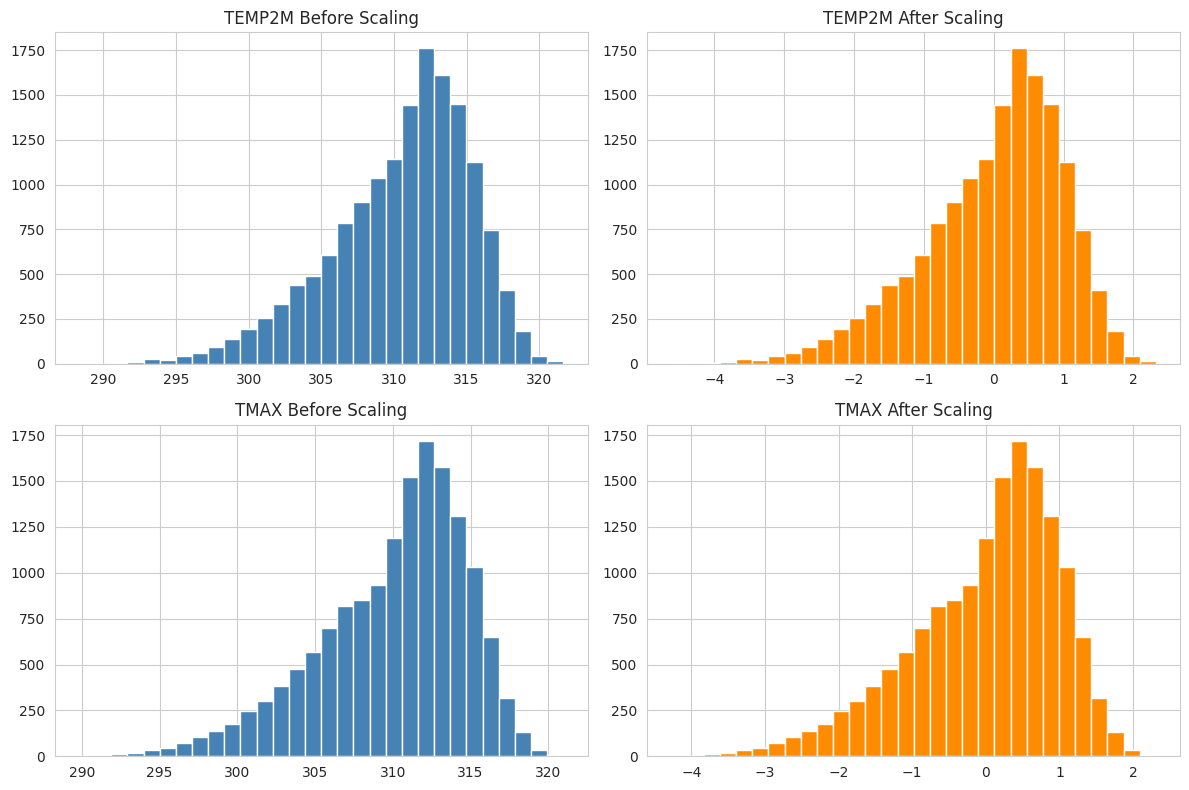

Scaling changes the x-axis range (centered near 0) but keeps the same distribution shape.


In [53]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(before_scaling_sample['TEMP2M'], bins=30, color='steelblue')
axes[0, 0].set_title('TEMP2M Before Scaling')

axes[0, 1].hist(X_train['TEMP2M'], bins=30, color='darkorange')
axes[0, 1].set_title('TEMP2M After Scaling')

axes[1, 0].hist(before_scaling_sample['TMAX'], bins=30, color='steelblue')
axes[1, 0].set_title('TMAX Before Scaling')

axes[1, 1].hist(X_train['TMAX'], bins=30, color='darkorange')
axes[1, 1].set_title('TMAX After Scaling')

plt.tight_layout()
plt.show()
print("Scaling changes the x-axis range (centered near 0) but keeps the same distribution shape.")

This cell demonstrates normalization separately from the main pipeline by applying a MinMaxScaler to a saved copy of the original, unscaled training data. The result is stored in its own DataFrame purely to show the technique, and it is never merged back into X_train or used in the rest of the notebook.


AI Disclaimer: AI (Gemini) was used to help write this code cell.
Prompt: "Write code that applies MinMaxScaler to a separate copy of the original unscaled numeric training data, stores the result in a new DataFrame with the original column names and index, and prints a sample — without modifying the main X_train DataFrame."

In [54]:
# --- Normalization (MinMaxScaler), demonstrated separately on the RAW values ---
minmax_scaler = MinMaxScaler()
normalized_demo = minmax_scaler.fit_transform(raw_numeric_train)
normalized_demo_df = pd.DataFrame(normalized_demo, columns=numeric_cols_to_scale, index=X_train.index)

print("Normalized training features sample (demo only, not used downstream):")
print(normalized_demo_df.head())

Normalized training features sample (demo only, not used downstream):
           YEAR     MONTH       DAY  WIND_U10  WIND_V10      MSLP       BLH  \
13479  0.526316  0.333333  0.933333  0.612776  0.461908  0.450573  0.843158   
4044   0.684211  0.000000  0.600000  0.660471  0.709411  0.521007  0.537653   
10001  0.052632  1.000000  0.900000  0.603585  0.733675  0.159782  0.293267   
7729   0.157895  0.333333  0.400000  0.603677  0.396100  0.419720  0.631626   
9479   0.894737  0.666667  0.800000  0.652002  0.468807  0.423732  0.305172   

           GEOP    TEMP2M      TMAX  ...     DEW2M     CLOUD      RAIN  \
13479  0.193484  0.830619  0.798772  ...  0.400918  0.057251  0.000000   
4044   0.213146  0.546208  0.510757  ...  0.491833  0.000000  0.000000   
10001  0.153584  0.570434  0.593436  ...  0.876323  0.784546  0.000000   
7729   1.000000  0.682425  0.667756  ...  0.497395  0.000000  0.000000   
9479   1.000000  0.449558  0.556193  ...  0.827245  0.252014  0.002893   

          

This cell plots histograms of the TEMP2M feature before and after MinMaxScaler was applied, showing how normalization compresses all values into a 0–1 range. It confirms the transformation worked correctly while preserving the original distribution's shape.

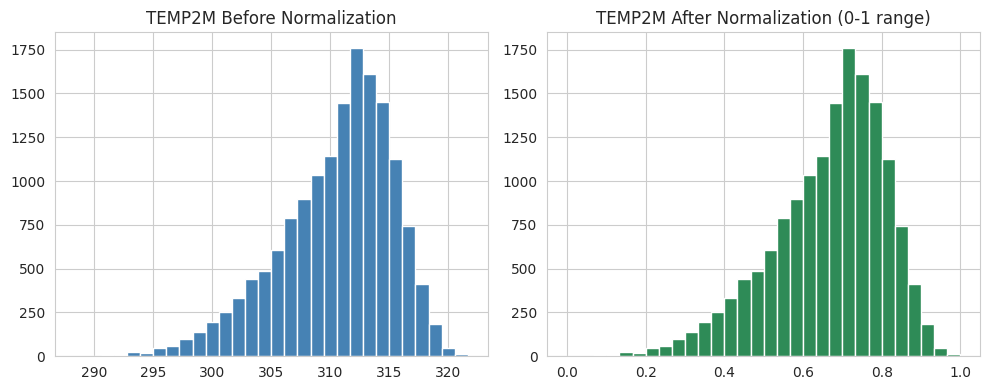

Normalization compresses values into a fixed 0-1 range.


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(raw_numeric_train['TEMP2M'], bins=30, color='steelblue')
axes[0].set_title('TEMP2M Before Normalization')
axes[1].hist(normalized_demo_df['TEMP2M'], bins=30, color='seagreen')
axes[1].set_title('TEMP2M After Normalization (0-1 range)')
plt.tight_layout()
plt.show()
print("Normalization compresses values into a fixed 0-1 range.")

This cell applies SMOTE to the training features and labels only, generating synthetic examples of the minority HEATWAVE class so the training set becomes balanced. It prints the class counts before and after balancing and plots the new distribution to confirm the fix worked.


AI Disclaimer: AI (Gemini) was used to help write this code cell.
Prompt: "Write code that applies SMOTE from imblearn to balance a training feature set and target array, prints the class value_counts before and after, and plots the balanced class distribution using seaborn's countplot."

Before SMOTE:
HEATWAVE
0    14603
1      769
Name: count, dtype: int64

After SMOTE:
HEATWAVE
0    14603
1    14603
Name: count, dtype: int64


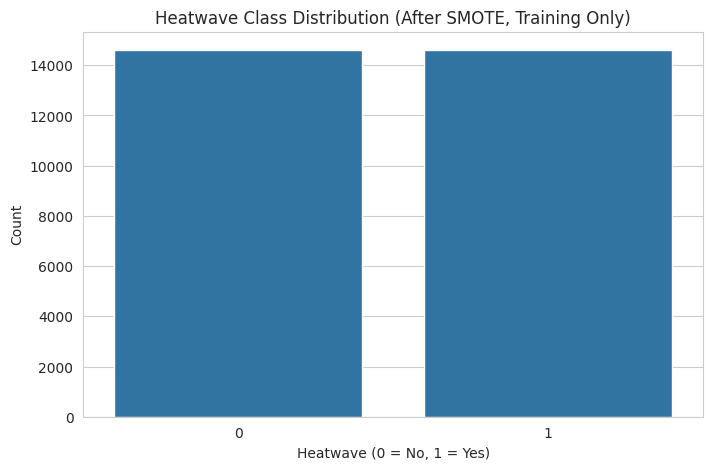

In [56]:
# SMOTE creates synthetic minority-class rows. We apply it ONLY to training
# data — the test set must stay untouched and reflect real-world proportions.
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_balanced)
plt.title('Heatwave Class Distribution (After SMOTE, Training Only)')
plt.xlabel('Heatwave (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

This cell prints the final shapes of the balanced training set and the untouched test set to confirm the pipeline worked as expected, and shows a sample of the fully processed training data. It then saves the training features, training labels, test features, and test labels each to their own CSV file for the GitHub submission.

In [57]:
print("Final training set shape:", X_train_balanced.shape)
print("Final test set shape (untouched, still imbalanced):", X_test.shape)

print("\nSample of processed training data:")
print(X_train_balanced.head())

# Save outputs
X_train_balanced.to_csv('train_processed.csv', index=False)
y_train_balanced.to_csv('train_labels.csv', index=False)
X_test.to_csv('test_processed.csv', index=False)
y_test.to_csv('test_labels.csv', index=False)
print("\nFiles saved.")

Final training set shape: (29206, 29)
Final test set shape (untouched, still imbalanced): (6588, 29)

Sample of processed training data:
       YEAR     MONTH       DAY  WIND_U10  WIND_V10      MSLP       BLH  \
0  0.084146 -0.443933  1.504147  0.065923 -0.214428  0.159967  2.068718   
1  0.604878 -1.339018  0.368607  0.472921  1.615292  0.587330  0.373781   
2 -1.478048  1.346238  1.390593 -0.012508  1.794666 -1.604435 -0.982069   
3 -1.130894 -0.443933 -0.312717 -0.011722 -0.700923 -0.027240  0.895143   
4  1.299187  0.451153  1.049931  0.400653 -0.163422 -0.002894 -0.916018   

       GEOP    TEMP2M      TMAX  ...       LAT       LON  DISTRICT_Bikaner  \
0 -0.550726  1.145079  0.984445  ... -0.693603 -0.416484             False   
1 -0.486398 -0.826509 -0.910211  ...  0.605314 -0.260603              True   
2 -0.681262 -0.658569 -0.366323  ... -0.136924 -1.663532             False   
3  2.087863  0.117768  0.122580  ... -0.136924  1.298208             False   
4  2.087863 -1.496506 

# Discussion:

Ranveer: So this is binary classification predicting HEATWAVE, 0 or 1, from the weather columns.


Trevor: Data's already clean, encoded, split, and scaled.


Freddy: And balanced with SMOTE. Heatwaves are rare in the raw data, so without that a model could just predict "no heatwave" every time and still look accurate.


John: For the model, Logistic Regression is the easy starting point since we already used it in our previous lab. Decision Trees could work better on this kind of data.


Ranveer: Also, our feature engineering step doesn't really do anything since YEAR/MONTH/DAY were already separate columns. I say we keep the cell in anyway in case the notebook needs to show that step.


Trevor: Makes sense. For evaluation, accuracy alone won't mean much because of the imbalance we should look at precision, recall, and F1 for the heatwave class specifically.


Freddy: ROC AUC too, for an overall sense of how well the model separates the classes.


John: And we'd tune whatever model we pick with GridSearchCV instead of guessing parameters.


Ranveer: For finals, we could also look at time patterns since we have actual dates, and check which weather features matter most that'd basically be the start of an early warning system.